# Taller Práctico 01 — Del Dato Crudo a la Decisión
## Recolección e inventario de activos (Individual/Diagnóstico)
1. Cargue los tres archivos de su conjunto de datos (`LIMPIO`, `CONTAMINADO`, `.json`) con `pandas`.
2. Construya un inventario: para cada variable, indique tipo de dato (nominal / ordinal /
   discreto / continuo / fecha / geoespacial), formato de origen (CSV, JSON anidado) y si
   proviene de una fuente estructurada o semi-estructurada.
3. Para el JSON: identifique campos anidados o listas (ej. lista de síntomas, diccionarios de
   ubicación) y decida cómo aplanarlos (`pd.json_normalize` o equivalente) para poder cruzarlos
   con el archivo tabular.

**Pregunta de reflexión (obligatoria en Markdown):** ¿qué información se pierde o se distorsiona
al forzar una fuente no estructurada/semi-estructurada dentro de una tabla rectangular?

In [181]:
import pandas as pd

# Importar datos
df_limpio = pd.read_csv("data/raw/movilidad_sensores_LIMPIO.csv")
df_contaminado = pd.read_csv("data/raw/movilidad_sensores_CONTAMINADO.csv")
df_clima = pd.read_json("data/raw/clima_api_log.json")

print("=============================")
print("HEAD DATOS LIMPIOS")
print("=============================")
print(df_limpio.head())
print("=============================")
print("HEAD DATOS CONTAMINADOS")
print("=============================")
print(df_contaminado.head())
print("=============================")
print("HEAD DATOS JSON")
print("=============================")
print(df_clima.head())
print("=============================")

print("INFO()")
print("=============================")
print("DATOS LIMPIOS")
print("=============================")
print(df_limpio.info())
print("=============================")
print("DATOS CONTAMINADOS")
print("=============================")
print(df_contaminado.info())
print("=============================")
print("DATOS JSON")
print("=============================")
print(df_clima.info())
print("=============================")

HEAD DATOS LIMPIOS
  sensor_id     ubicacion tipo_via            timestamp  conteo_vehiculos  \
0     SEN01  Av. Regional  Troncal  2025-03-01 00:00:00                10   
1     SEN01  Av. Regional  Troncal  2025-03-01 02:00:00                14   
2     SEN01  Av. Regional  Troncal  2025-03-01 04:00:00                 9   
3     SEN01  Av. Regional  Troncal  2025-03-01 06:00:00                43   
4     SEN01  Av. Regional  Troncal  2025-03-01 08:00:00                42   

   temperatura_c condicion_clima      lat       lon  
0           25.3         Soleado  6.23148 -75.58964  
1           26.8         Soleado  6.22994 -75.59105  
2           23.8         Soleado  6.23109 -75.59060  
3           22.5         Soleado  6.23140 -75.59091  
4           21.2          Lluvia  6.23179 -75.59126  
HEAD DATOS CONTAMINADOS
  sensor_id        ubicacion tipo_via            timestamp  conteo_vehiculos  \
0     SEN03         Calle 10    Local  2025-03-09 16:00:00              31.0   
1     SEN0

**Descubrimiento:** Se observa que las columna `location` y `weather` son objetos json anidados que debemos aplanar antes de realizar el inventario de variables.

In [182]:
# Aplanar la información de ubicación
location_df = pd.json_normalize(df_clima["location"])

# Aplanar la información del clima
weather_df = pd.json_normalize(df_clima["weather"])

# Unir todo en un único DataFrame
df_clima_flat = pd.concat(
    [
        df_clima.drop(columns=["location", "weather"]),
        location_df,
        weather_df,
    ],
    axis=1,
)

print("=============================")
print("DATOS APLANADOS JSON")
print("=============================")
print(df_clima_flat.info())
print("=============================")
print("HEAD DATOS APLANADOS JSON")
print("=============================")
print(df_clima_flat.head())
print("=============================")

DATOS APLANADOS JSON
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   request_id    120 non-null    object        
 1   timestamp     120 non-null    datetime64[ns]
 2   sensor_id     120 non-null    object        
 3   lat           120 non-null    float64       
 4   lon           120 non-null    float64       
 5   temp_c        116 non-null    float64       
 6   condition     120 non-null    object        
 7   humidity_pct  120 non-null    int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 7.6+ KB
None
HEAD DATOS APLANADOS JSON
  request_id           timestamp sensor_id     lat      lon  temp_c condition  \
0      W0001 2025-03-17 14:00:00     SEN02  6.2145 -75.5734    26.2    Lluvia   
1      W0002 2025-03-18 05:00:00     SEN03  6.2093 -75.5710    26.0    Lluvia   
2      W0003 2025-03

> Declaración de uso de IA.

Se usó para la generación del código que aplana una variable de tipo JSON en el dataframe original. Con los resultados el equipo pudo construir el inventario de variables presentado a continuación.

### Inventario de Variables

#### 1. Archivo `movilidad_sensores_LIMPIO.csv`
| Variable         | Tipo de dato | Formato | Fuente       |
| ---------------- | ------------ | ------- | ------------ |
| sensor_id        | Nominal      | CSV     | Estructurada |
| ubicacion        | Nominal      | CSV     | Estructurada |
| tipo_via         | Nominal      | CSV     | Estructurada |
| timestamp        | Fecha        | CSV     | Estructurada |
| conteo_vehiculos | Discreta     | CSV     | Estructurada |
| temperatura_c    | Continua     | CSV     | Estructurada |
| condicion_clima  | Nominal      | CSV     | Estructurada |
| lat              | Geoespacial  | CSV     | Estructurada |
| lon              | Geoespacial  | CSV     | Estructurada |

#### Archivo `clima_api_log.json`
| Variable | Tipo de dato | Formato | Fuente |
| ------------ | ------------ | ------- | ----------------- |
| request_id   | Nominal      | JSON    | Semi-estructurada |
| timestamp    | Fecha        | JSON    | Semi-estructurada |
| sensor_id    | Nominal      | JSON    | Semi-estructurada |
| lat          | Geoespacial  | JSON    | Semi-estructurada |
| lon          | Geoespacial  | JSON    | Semi-estructurada |
| temp_c       | Continua     | JSON    | Semi-estructurada |
| condition    | Nominal      | JSON    | Semi-estructurada |
| humidity_pct | Discreta     | JSON    | Semi-estructurada |

### Pregunta de Reflexión
> ¿Qué información se pierde o se distorsiona al forzar una fuente no estructurada/semi-estructurada dentro de una tabla rectangular?

Como equipo consideramos que al transformar una fuente semi-estructurada como fue el caso de este ejercicio modificamos la estructura base anidada que tiene el formato JSON, aplanando los valores a una estructura tabular; porque de no aplanarse la información sería muy difícil de evaluar visualmente e incluso para Pandas se le dificulta clasificar las variables individualmente y solo toma tipos de datos `object`. Adicionalmente, en el proceso de transformación del formato anidado a tabular vemos que se pierde el nombres de la variable externa `location` y `weather`, pero no creemos que sea una perdida de información tan crítica para el análisis de este ejercicio.

# Diagnóstico GIGO sobre el archivo contaminado
Sin corregir todavía, documenten en una tabla Markdown dentro del notebook:

| Problema detectado | Columna(s) afectada(s) | Método de detección en pandas | ¿Por qué es un riesgo para la decisión de negocio? |
|---|---|---|---|

Deben identificar **al menos 6 problemas distintos**, cubriendo como mínimo:
- Completitud (valores faltantes).
- Unicidad (duplicados exactos y duplicados de "evento de negocio").
- Consistencia de categorías (mayúsculas, sinónimos, espacios).
- Formatos de fecha/hora mixtos.
- Valores imposibles o fuera de rango (edades, conteos negativos, ratings fuera de escala).
- Errores de georreferenciación (coordenadas invertidas, en cero, o fuera del área de Medellín).

DATOS NULOS
Registros con valores nulos: 
 sensor_id             0
ubicacion             0
tipo_via              0
timestamp             0
conteo_vehiculos    145
temperatura_c        72
condicion_clima      87
lat                   0
lon                   0
dtype: int64
Registros con valores nan: 
 sensor_id             0
ubicacion             0
tipo_via              0
timestamp             0
conteo_vehiculos    145
temperatura_c        72
condicion_clima      87
lat                   0
lon                   0
dtype: int64
DATOS DUPLICADOS
Registros duplicados en datos contaminados: 7
Duplicados negocio (mismo sensor en mismo instante de tiempo): 14
DATOS CONSISTENCIA
Consistencia categorica condicion_clima ['LLUVIA', 'Lluvia', 'Nubes', 'Nublado', 'SOLEADO', 'Sol', 'Soleado', 'lluvia', 'lluvioso', 'nublado', 'soleado']
Consistencia categorica tipo_via ['Arteria', 'Local', 'Troncal']
sensor_id: 0 valores con espacios
ubicacion: 0 valores con espacios
tipo_via: 0 valores con espacios
ti

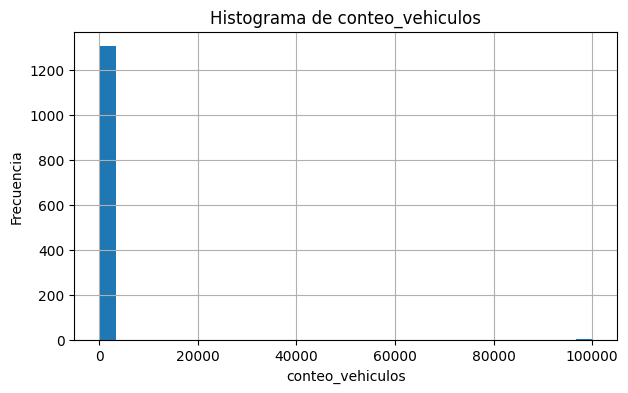

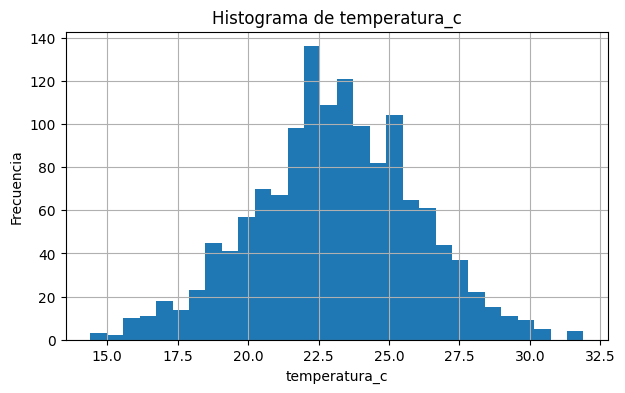

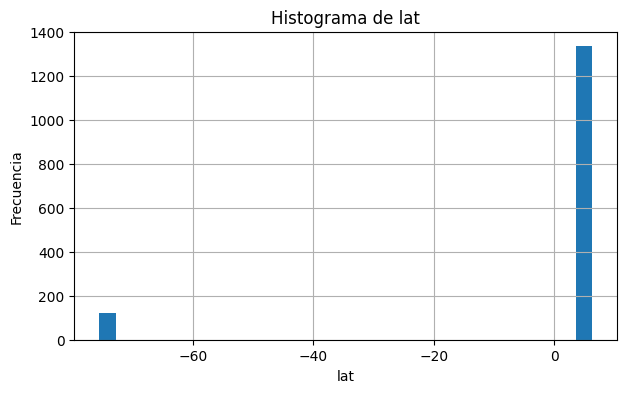

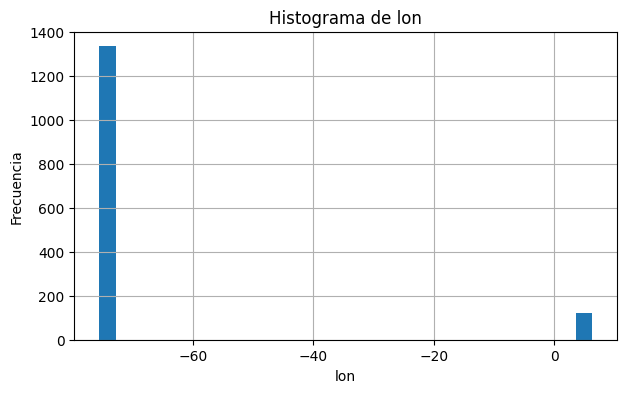


Variable: conteo_vehiculos
Q1: 13.00
Q3: 35.00
IQR: 22.00
Límite inferior: -20.00
Límite superior: 68.00
Outliers encontrados: 4

Variable: temperatura_c
Q1: 21.20
Q3: 25.00
IQR: 3.80
Límite inferior: 15.50
Límite superior: 30.70
Outliers encontrados: 9

Variable: lat
Q1: 6.21
Q3: 6.25
IQR: 0.03
Límite inferior: 6.16
Límite superior: 6.29
Outliers encontrados: 121

Variable: lon
Q1: -75.59
Q3: -75.57
IQR: 0.02
Límite inferior: -75.61
Límite superior: -75.54
Outliers encontrados: 121
DATOS GEORREFERENCIACION
Coordenadas fuera de Medellín: 121
Posibles coordenadas invertidas: 121


In [193]:
# Nulos
print("=============================")
print("DATOS NULOS")
print("=============================")
print(f"Registros con valores nulos: \n {df_contaminado.isnull().sum()}")
print(f"Registros con valores nan: \n {df_contaminado.isna().sum()}")

# Duplicados
print("=============================")
print("DATOS DUPLICADOS")
print("=============================")
print("Registros duplicados en datos contaminados:", df_contaminado.duplicated().sum())
duplicados_negocio = df_contaminado.duplicated(
    subset=["sensor_id", "timestamp"]
).sum()
print(f"Duplicados negocio (mismo sensor en mismo instante de tiempo): {duplicados_negocio}")

# Consistencia de Variables
print("=============================")
print("DATOS CONSISTENCIA")
print("=============================")
print("Consistencia categorica condicion_clima", sorted(df_contaminado["condicion_clima"].dropna().unique()))
print("Consistencia categorica tipo_via",sorted(df_contaminado["tipo_via"].dropna().unique()))
columnas_texto = df_contaminado.select_dtypes(include="object").columns
for columna in columnas_texto:
    con_espacios = (
        df_contaminado[columna]
        .dropna()
        .str.startswith(" ")
        | df_contaminado[columna]
        .dropna()
        .str.endswith(" ")
    ).sum()

    print(f"{columna}: {con_espacios} valores con espacios")

# Formatos de Fechas
print("=============================")
print("DATOS FECHAS")
print("=============================")
fechas_contaminado = pd.to_datetime(
    df_contaminado["timestamp"],
    errors="coerce"
)
print("Fechas inválida:", fechas_contaminado.isna().sum())
print(df_contaminado.loc[fechas_contaminado.isna(), "timestamp"])

# Variables Fuera de Rango
print("=============================")
print("DATOS FUERA DE RANGO")
print("=============================")
humedad_fuera_rango = df_clima_flat[
    (df_clima_flat["humidity_pct"] < 0) |
    (df_clima_flat["humidity_pct"] > 100)
]
print("Humedad fuera de rango:", humedad_fuera_rango.shape[0])

temperaturas_invalidas = df_contaminado[
    (df_contaminado["temperatura_c"] < 10) |
    (df_contaminado["temperatura_c"] > 40)
]
print("Temperatura fuera de rango:", temperaturas_invalidas.shape[0])

lat_invalidas = df_contaminado[
    (df_contaminado["lat"] < -90) |
    (df_contaminado["lat"] > 90)
]
print("Latitudes fuera de rango:", lat_invalidas.shape[0])

lon_invalidas = df_contaminado[
    (df_contaminado["lon"] < -180) |
    (df_contaminado["lon"] > 180)
]
print("Longitudes fuera de rango:", lon_invalidas.shape[0])

conteo_negativo = df_contaminado[
    df_contaminado["conteo_vehiculos"] < 0
]
print("Conteo vehículos negativo:", conteo_negativo.shape[0])

def detectar_outliers_iqr(df, columna, print_detalle = True):
    """
    Detecta valores atípicos utilizando el método del IQR.
    """

    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]
    if print_detalle:
      print(f"\nVariable: {columna}")
      print(f"Q1: {q1:.2f}")
      print(f"Q3: {q3:.2f}")
      print(f"IQR: {iqr:.2f}")
      print(f"Límite inferior: {limite_inferior:.2f}")
      print(f"Límite superior: {limite_superior:.2f}")
      print(f"Outliers encontrados: {len(outliers)}")
    else:
      print(f"Variable: {columna} - Outliers encontrados: {len(outliers)}")

    return outliers

import matplotlib.pyplot as plt

variables_numericas = [
    "conteo_vehiculos",
    "temperatura_c",
    "lat",
    "lon"
]

for variable in variables_numericas:
    plt.figure(figsize=(7,4))

    df_contaminado[variable].dropna().hist(bins=30)

    plt.title(f"Histograma de {variable}")
    plt.xlabel(variable)
    plt.ylabel("Frecuencia")

    plt.show()

for variable in variables_numericas:
    detectar_outliers_iqr(df_contaminado, variable)

# Errores de Georreferenciación
print("=============================")
print("DATOS GEORREFERENCIACION")
print("=============================")
LAT_MIN = 6.15
LAT_MAX = 6.35

LON_MIN = -75.70
LON_MAX = -75.45
fuera_medellin = df_contaminado[
    (df_contaminado["lat"] < LAT_MIN) |
    (df_contaminado["lat"] > LAT_MAX) |
    (df_contaminado["lon"] < LON_MIN) |
    (df_contaminado["lon"] > LON_MAX)
]

print(f"Coordenadas fuera de Medellín: {len(fuera_medellin)}")

coordenadas_invertidas = df_contaminado[
    (df_contaminado["lat"].between(LON_MIN, LON_MAX)) &
    (df_contaminado["lon"].between(LAT_MIN, LAT_MAX))
]

print(f"Posibles coordenadas invertidas: {len(coordenadas_invertidas)}")

> Declaración de uso de IA.

Se usó para la generación de muchas de las funciones que me permiten identificar errores en los datos de la fuente contaminada, también se hizo uso de esta para identificar las coordenadas límite de medellín y los límites de variables como la temperatura y la humedad.

### Diagnóstico GIGO

| Problema detectado | Columna(s) afectada(s) | Método de detección en Pandas | ¿Por qué es un riesgo para la decisión de negocio? |
| ------------------ | ---------------------- | ------------------- | ------------------------------------------------------------------------- |
| Valores nulos | `conteo_vehiculos`, `temperatura_c`, `condicion_clima` | `isnull()` y `isna()` | La ausencia de información puede producir análisis incompletos y afectar los cálculos numéricos para las variables afectadas. Si estos cálculos están erroneos puede afectar nuestra decisión hacia un camino diferente al que si estuvieran correctos. |
| Registros duplicados | Todas las columnas | `duplicated()` | Tener en cuenta un mismo evento afecta indicadores o cálculos en su procesamiento que podría mostrar resultados erroneos con los que nosotros tomaremos la decisión de la semaforización inteligente. |
| Duplicados de negocio | `sensor_id`, `timestamp` | `duplicated(subset=["sensor_id","timestamp"])` | Un sensor no debería registrar dos mediciones para el mismo instante, este tipo de casos también son duplicados. |
| Inconsistencia en variables categóricas | `condicion_clima` | `unique()` y `value_counts()` | Valores diferentes de una misma categoría (`LLUVIA`, `lluvia`, `Lluvia`) nos impiden agrupar valores por dicha categoría y puede entorpecer los cálculos y análisis visual (gráficas). |
| Formatos de fecha inconsistentes | `timestamp` | `pd.to_datetime(errors="coerce")` | Impide ordenar cronológicamente los registros y dificulta analizar los horarios de mayor congestión, afectando directamente la decisión de negocio. |
| Valores fuera del dominio permitido | `conteo_vehiculos` | Filtros por reglas de negocio (`< 0`) | Un conteo negativo de vehículos es físicamente imposible y este valor puede afectar los cálculos que se hagan con esta variable. |
| Valores fuera del dominio permitido | `conteo_vehiculos` | Filtros por fórmula `Límite inferior: Q1 - 1.5 × IQR <= valor <= Límite superior: Q3 + 1.5 × IQR` | Los outliers son valores que pueden entorpecer el análisis principalmente visual de la información procesada. |
| Coordenadas posiblemente invertidas | `lat`, `lon` | Filtros por rangos geográficos | Si los registros no son de Medellín, pueden estar capturando temperaturas y flujo de vehículos no válidos para el alcance del ejercicio, lo que afecta los resultados del procesamiento y análisis de los datos y, por tanto, la decisión final. Si los registros están invertidos, no estaríamos tomando valores correctos que son importantes para la decisión.  |


## Transformación y limpieza con pandas
Corrijan cada problema documentado en la Tarea 2. Por cada transformación, el notebook debe
tener: (a) el código, (b) una celda Markdown justificando **la decisión** (no solo la sintaxis).
Ejemplos de decisiones que deben justificar explícitamente:
- ¿Imputar con media, mediana, moda, un valor centinela, o eliminar la fila? ¿Por qué esa y no otra?
- ¿Cómo definieron el rango geográfico válido para Medellín y qué hicieron con las coordenadas
  fuera de rango: corregir automáticamente o descartar?
- ¿Qué llave de negocio usaron para detectar duplicados reales (no solo `.duplicated()` ingenuo)?}

### Valores Nulos

In [184]:
df_contaminado_transformado = df_contaminado.copy()

print(f"Registros con valores nulos (Antes): \n {df_contaminado_transformado["conteo_vehiculos"].isnull().sum()}")
df_contaminado_transformado["conteo_vehiculos"] = (
    df_contaminado_transformado
    .groupby("sensor_id")["conteo_vehiculos"]
    .transform(lambda x: x.fillna(x.median()))
)
print(f"Registros con valores nulos (Después): \n {df_contaminado_transformado["conteo_vehiculos"].isnull().sum()}")

Registros con valores nulos (Antes): 
 145
Registros con valores nulos (Después): 
 0


#### Imputación con Mediana por Sensor
1. Se decidió imputar valores, no se eliminan las filas de los conteos de vehículos no nulos porque son 145 valores nulos de un total de 1455 (10% apróx), estaríamos muchos datos.
2. Si se usaba una mediana general, podría dar valores muy poco probables para algunos sensores que podrían tener diferentes mediana.
3. No usamos la moda porque en caso de ser un valor no tan cercano a la media, podríamos estar afectando la distribución de nuestros datos. La media tampoco la usamos porque esta tiene en cuenta los ouliers, mientras que la mediana es más neutral frente a estos valores atípicos.



In [185]:
print(f"Registros con valores nulos (Antes): \n {df_contaminado_transformado["temperatura_c"].isnull().sum()}")
df_contaminado_transformado["temperatura_c"] = (
    df_contaminado_transformado
    .groupby("sensor_id")["temperatura_c"]
    .transform(lambda x: x.fillna(x.median()))
)
print(f"Registros con valores nulos (Después): \n {df_contaminado_transformado["temperatura_c"].isnull().sum()}")

Registros con valores nulos (Antes): 
 72
Registros con valores nulos (Después): 
 0


#### Imputación con Mediana por Sensor
1. Se decidió imputar valores, no se eliminan las filas de los conteos de vehículos no nulos porque son 145 valores nulos de un total de 72 (5% apróx), estaríamos eliminando una cantidad importante de datos. Adicionalmente, al contar con la posibilidad de agrupar las principales variables estadísticas por sensor, podemos imputar de manera un poco más precisa.
2. Si se usaba una mediana general, podría dar valores muy poco probables para algunos sensores que podrían tener diferentes mediana.
3. No usamos la moda porque en caso de ser un valor no tan cercano a la media, podríamos estar afectando la distribución de nuestros datos. La media tampoco la usamos porque esta tiene en cuenta los ouliers, mientras que la mediana es más neutral frente a estos valores atípicos.



In [186]:
print(f"Registros con valores nulos (Antes): \n {df_contaminado_transformado["condicion_clima"].isnull().sum()}")
df_contaminado_transformado["condicion_clima"] = (
    df_contaminado_transformado
    .groupby("sensor_id")["condicion_clima"]
    .transform(
        lambda x: x.fillna(x.mode().iloc[0])
    )
)
print(f"Registros con valores nulos (Después): \n {df_contaminado_transformado["condicion_clima"].isnull().sum()}")

Registros con valores nulos (Antes): 
 87
Registros con valores nulos (Después): 
 0


#### Imputación con Moda por Sensor
1. Se decidió imputar valores, no se eliminan las filas de los conteos de vehículos no nulos porque son 145 valores nulos de un total de 87 (6% apróx), estaríamos eliminando una cantidad importante de datos. Adicionalmente, al contar con la posibilidad de agrupar las principales variables estadísticas por sensor, podemos imputar de manera un poco más precisa.
2. Decidimos usar la moda porque es mucho más probable calcular bien la condición climática con base en lo más frecuente por cada zona o sensor que con cálculos basados en la temperatura que pueden no cumplirse para todas las zonas o sensores.

### Valores Duplicados



In [187]:
print("Registros duplicados en datos contaminados (Antes):", df_contaminado_transformado.duplicated().sum())
df_contaminado_transformado = df_contaminado_transformado.drop_duplicates()
print("Registros duplicados en datos contaminados (Después):", df_contaminado_transformado.duplicated().sum())
duplicados_negocio = df_contaminado_transformado.duplicated(
    subset=["sensor_id", "timestamp"]
).sum()
print(f"Duplicados negocio (mismo sensor en mismo instante de tiempo) (Antes): {duplicados_negocio}")
print(f"Longitud fuente de datos (Antes): {df_contaminado_transformado.shape[0]}")
duplicados_negocio = (
    df_contaminado_transformado[
        df_contaminado_transformado.duplicated(
            subset=["sensor_id", "timestamp"],
            keep=False
        )
    ]
    .sort_values(["sensor_id", "timestamp"])
)

print(duplicados_negocio)
claves_duplicadas = (
    df_contaminado_transformado
    .loc[
        df_contaminado_transformado.duplicated(
            subset=["sensor_id", "timestamp"],
            keep=False
        ),
        ["sensor_id", "timestamp"]
    ]
    .drop_duplicates()
)
df_contaminado_transformado = (
    df_contaminado_transformado
    .merge(
        claves_duplicadas,
        on=["sensor_id", "timestamp"],
        how="left",
        indicator=True
    )
    .query("_merge == 'left_only'")
    .drop(columns="_merge")
)
duplicados_negocio = df_contaminado_transformado.duplicated(
    subset=["sensor_id", "timestamp"]
).sum()
print(f"Duplicados negocio (mismo sensor en mismo instante de tiempo) (Despues): {duplicados_negocio}")
print(f"Longitud fuente de datos (Despues): {df_contaminado_transformado.shape[0]}")


Registros duplicados en datos contaminados (Antes): 8
Registros duplicados en datos contaminados (Después): 0
Duplicados negocio (mismo sensor en mismo instante de tiempo) (Antes): 6
Longitud fuente de datos (Antes): 1447
     sensor_id        ubicacion tipo_via            timestamp  \
16       SEN01     Av. Regional  Troncal  2025-03-08 04:00:00   
1028     SEN01     Av. Regional  Troncal  2025-03-08 04:00:00   
49       SEN01     Av. Regional  Troncal  2025-03-11 20:00:00   
951      SEN01     Av. Regional  Troncal  2025-03-11 20:00:00   
369      SEN04  Autopista Norte  Troncal  2025-03-04 22:00:00   
1147     SEN04  Autopista Norte  Troncal  2025-03-04 22:00:00   
346      SEN04  Autopista Norte  Troncal  2025-03-15 00:00:00   
1204     SEN04  Autopista Norte  Troncal  2025-03-15 00:00:00   
611      SEN05     Av. Oriental  Arteria  2025-03-03 04:00:00   
1168     SEN05     Av. Oriental  Arteria  2025-03-03 04:00:00   
1088     SEN06     Circular 4ta    Local  2025-03-08 22:00:00  

#### Eliminación
- Los registros completamente iguales simplemente no son necesario, por lo que se eliminan los duplicados y se queda solo con un registro.
- Los registros de negocio por ser pocos se decide eliminar ambos registros. Aunque el cambio es mínimo, porque solo difieren en el conteo de vehículos, no tenemos forma de verificar cuál es el registro correcto. Adicionalmente, tenemos muy pocos datos duplicados por regla de negocio, no afecta tanto nuestra fuente de información y solo estaríamos eliminando 6 datos correctos (los otros 6 eran los incorrectos).
- La llave de duplicados de negocio fue el sensor y el instante de tiempo ya que no tiene sentido tener 2 registros de un sensor en el mismo instante de tiempo.

### Inconsistencia en Variables Categoricas


In [188]:
mapa_clima = {
    "SOLEADO": "Soleado",
    "soleado": "Soleado",
    "Sol": "Soleado",
    "Soleado": "Soleado",

    "Nublado": "Nublado",
    "nublado": "Nublado",
    "Nubes": "Nublado",

    "LLUVIA": "Lluvia",
    "lluvia": "Lluvia",
    "Lluvia": "Lluvia",
    "lluvioso": "Lluvia"
}

print("Consistencia categorica condicion_clima (Antes)", sorted(df_contaminado["condicion_clima"].dropna().unique()))

df_contaminado_transformado["condicion_clima"] = (
    df_contaminado_transformado["condicion_clima"]
    .map(mapa_clima)
)

print("Consistencia categorica condicion_clima (Después)", sorted(df_contaminado_transformado["condicion_clima"].dropna().unique()))

Consistencia categorica condicion_clima (Antes) ['LLUVIA', 'Lluvia', 'Nubes', 'Nublado', 'SOLEADO', 'Sol', 'Soleado', 'lluvia', 'lluvioso', 'nublado', 'soleado']
Consistencia categorica condicion_clima (Después) ['Lluvia', 'Nublado', 'Soleado']


#### Mapear Posibles Valores y Categoría

Se decidió implementar un mapeo de todas las categorías que tenía el conjunto de datos y tranformarlo en la verdadera categoría para unificar los sinónimos y valores que no hicieran match por mayúsculas o minusculas. Se decidió esta opción principalmente por los sinónimos.

### Formatos de Fechas

In [189]:
fechas_contaminado = pd.to_datetime(
    df_contaminado_transformado["timestamp"],
    errors="coerce"
)
print("Fechas inválidas (Antes:", fechas_contaminado.isna().sum())
print(df_contaminado_transformado.loc[fechas_contaminado.isna(), "timestamp"])

def convertir_fecha(valor):
    if pd.isna(valor):
        return pd.NaT

    valor = str(valor).strip()

    # 1. Timestamp Unix
    if valor.isdigit():
        return pd.to_datetime(int(valor), unit="s")

    # 2. Reemplazar el texto para el formato "17 de March de 2025"
    valor = valor.replace(" de ", " ")
    valor = valor.replace(",", "")

    formatos = [
        "%d/%m/%Y %H:%M",
        "%Y-%m-%dT%H:%M:%SZ",
        "%d %B %Y %H:%M",
        "%Y-%m-%d %H:%M:%S"
    ]

    for formato in formatos:
        try:
            return pd.to_datetime(valor, format=formato)
        except:
            pass

    return pd.NaT

df_contaminado_transformado["timestamp"] = (
    df_contaminado_transformado["timestamp"]
    .apply(convertir_fecha)
)
fechas_contaminado = pd.to_datetime(
    df_contaminado_transformado["timestamp"],
    errors="coerce"
)
print("Fechas inválidas (Antes:", fechas_contaminado.isna().sum())
print(df_contaminado_transformado.loc[fechas_contaminado.isna(), "timestamp"])

Fechas inválidas (Antes: 90
34                      1740880800
48                13/03/2025 02:00
100           2025-03-09T06:00:00Z
103           2025-03-18T04:00:00Z
105               19/03/2025 06:00
                   ...            
1388              12/03/2025 14:00
1401              04/03/2025 08:00
1403          2025-03-19T20:00:00Z
1426    17 de March de 2025, 08:00
1445    18 de March de 2025, 20:00
Name: timestamp, Length: 90, dtype: object
Fechas inválidas (Antes: 0
Series([], Name: timestamp, dtype: datetime64[ns])


#### Corrección de Formato

Se decidió corregir el formato de las fechas ya que son muchos registros para eliminar 90 lo que puede afectar mucho nuestra fuente de datos para el análisis. Se uso IA para realizar esta corrección de formatos.

### Valores fuera de rango

In [190]:

conteo_negativo = df_contaminado_transformado[
    df_contaminado_transformado["conteo_vehiculos"] < 0
]
print("Conteo vehículos negativo:", conteo_negativo.shape[0])

df_contaminado_transformado = df_contaminado_transformado[
    df_contaminado_transformado["conteo_vehiculos"] >= 0
]

conteo_negativo = df_contaminado_transformado[
    df_contaminado_transformado["conteo_vehiculos"] < 0
]
print("Conteo vehículos negativo:", conteo_negativo.shape[0])

print("Fuera de Rango (Antes)")
for variable in variables_numericas:
    detectar_outliers_iqr(df_contaminado_transformado, variable, False)

q1 = df_contaminado_transformado["conteo_vehiculos"].quantile(0.25)
q3 = df_contaminado_transformado["conteo_vehiculos"].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

df_contaminado_transformado = df_contaminado_transformado[
    df_contaminado_transformado["conteo_vehiculos"].between(
        limite_inferior,
        limite_superior
    )
]

print("Fuera de Rango (Despues)")
for variable in variables_numericas:
    detectar_outliers_iqr(df_contaminado_transformado, variable, False)

Conteo vehículos negativo: 6
Conteo vehículos negativo: 0
Fuera de Rango (Antes)
Variable: conteo_vehiculos - Outliers encontrados: 4
Variable: temperatura_c - Outliers encontrados: 24
Variable: lat - Outliers encontrados: 118
Variable: lon - Outliers encontrados: 118
Fuera de Rango (Despues)
Variable: conteo_vehiculos - Outliers encontrados: 0
Variable: temperatura_c - Outliers encontrados: 24
Variable: lat - Outliers encontrados: 118
Variable: lon - Outliers encontrados: 118


#### Eliminación
1. Para los valores negativos de conteo de vehículos elimine todos los valores ya que es algo que no puede suceder y es un error que es mejor no tener en cuenta en los cálculos.
2. Para el tema de los outliers, gracias a los histogramas notamos que solo el conteo de los vehículos tenía outliers que realmente afectaban la fuente de datos, los otros tenían coportamientos dentro de lo normal. Por lo que solo se eliminaron los outliers de la columna de conteo de los vehículos.

### Coordenadas Fuera de Medellín



In [191]:
coordenadas_invertidas = df_contaminado_transformado[
    (df_contaminado_transformado["lat"].between(LON_MIN, LON_MAX)) &
    (df_contaminado_transformado["lon"].between(LAT_MIN, LAT_MAX))
]

print(f"Posibles coordenadas invertidas (Antes): {len(coordenadas_invertidas)}")

mascara = (
    df_contaminado_transformado["lat"].between(LON_MIN, LON_MAX) &
    df_contaminado_transformado["lon"].between(LAT_MIN, LAT_MAX)
)

df_contaminado_transformado.loc[mascara, ["lat", "lon"]] = (
    df_contaminado_transformado.loc[mascara, ["lon", "lat"]].to_numpy()
)

coordenadas_invertidas = df_contaminado_transformado[
    (df_contaminado_transformado["lat"].between(LON_MIN, LON_MAX)) &
    (df_contaminado_transformado["lon"].between(LAT_MIN, LAT_MAX))
]

print(f"Posibles coordenadas invertidas (Después): {len(coordenadas_invertidas)}")

Posibles coordenadas invertidas (Antes): 118
Posibles coordenadas invertidas (Después): 0


#### Inversión de Columnas
- Ya que las columnas de latitud y longitud se encontraban invertidas, simplemente se invirtieron estas columnas para corregir sus valores.

In [192]:
df_contaminado_transformado.to_csv(
    "contaminado_transformado.csv",
    index=False,
    encoding="utf-8"
)

print("Archivo 'contaminado_transformado.csv' guardado correctamente.")

Archivo 'contaminado_transformado.csv' guardado correctamente.
